In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!pip install beautifulsoup4 requests -q
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [8]:
url = "https://books.toscrape.com/catalogue/page-1.html"
response = requests.get(url)
print("Status code:", response.status_code)   # 200 matlab success

soup = BeautifulSoup(response.text, 'html.parser')
print(soup.prettify()[:2000])   # HTML structure dekhne ke liye

Status code: 200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js" lang="en-us">
 <!--<![endif]-->
 <head>
  <title>
   All products | Books to Scrape - Sandbox
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta content="24th Jun 2016 09:30" name="created"/>
  <meta content="" name="description"/>
  <meta content="width=device-width" name="viewport"/>
  <meta content="NOARCHIVE,NOCACHE" name="robots"/>
  <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
  <!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
  <link href="../static/oscar/favicon.ico" rel="shortcut icon"/>
  <link href="../static/oscar/css/styles.css" rel

In [9]:
import re
books = soup.find_all('article', class_='product_pod')
print("Books found on this page:", len(books))

first_book = books[0]
title = first_book.h3.a['title']

# Price ko clean karke dikhao (encoding fix)
raw_price = first_book.find('p', class_='price_color').text
clean_price = re.findall(r'[\d.]+', raw_price)[0]

rating = first_book.p['class'][1]
availability = first_book.find('p', class_='instock availability').text.strip()

print("Title:", title)
print("Price: £" + clean_price)
print("Rating:", rating)
print("Availability:", availability)

Books found on this page: 20
Title: A Light in the Attic
Price: £51.77
Rating: Three
Availability: In stock


In [10]:
all_books = []

for page in range(1, 21):   # 20 pages, ~1000 books total
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)

    if response.status_code != 200:
        break

    soup = BeautifulSoup(response.text, 'html.parser')
    books = soup.find_all('article', class_='product_pod')

    for book in books:
        title = book.h3.a['title']
        price = book.find('p', class_='price_color').text
        rating = book.p['class'][1]
        availability = book.find('p', class_='instock availability').text.strip()

        all_books.append({
            'title': title,
            'price': price,
            'rating': rating,
            'availability': availability
        })

print("Total books scraped:", len(all_books))

Total books scraped: 400


In [11]:
df = pd.DataFrame(all_books)
print(df.head(10))
print(df.shape)
print(df.dtypes)

                                               title    price rating  \
0                               A Light in the Attic  Â£51.77  Three   
1                                 Tipping the Velvet  Â£53.74    One   
2                                         Soumission  Â£50.10    One   
3                                      Sharp Objects  Â£47.82   Four   
4              Sapiens: A Brief History of Humankind  Â£54.23   Five   
5                                    The Requiem Red  Â£22.65    One   
6  The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four   
7  The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three   
8  The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four   
9                                    The Black Maria  Â£52.15    One   

  availability  
0     In stock  
1     In stock  
2     In stock  
3     In stock  
4     In stock  
5     In stock  
6     In stock  
7     In stock  
8     In stock  
9     In stock  
(400, 4)
title      

In [12]:
import re

# Regex se sirf number nikalo (digits + decimal point)
df['price'] = df['price'].apply(lambda x: float(re.findall(r'[\d.]+', x)[0]))

# Rating text ko number mein convert karo
rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df['rating'] = df['rating'].map(rating_map)

# Availability ko simplify karo
df['in_stock'] = df['availability'].apply(lambda x: 'In stock' in x)

print(df.head())
print(df.dtypes)

                                   title  price  rating availability  in_stock
0                   A Light in the Attic  51.77       3     In stock      True
1                     Tipping the Velvet  53.74       1     In stock      True
2                             Soumission  50.10       1     In stock      True
3                          Sharp Objects  47.82       4     In stock      True
4  Sapiens: A Brief History of Humankind  54.23       5     In stock      True
title            object
price           float64
rating            int64
availability     object
in_stock           bool
dtype: object


In [13]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (400, 5)

Missing Values:
title           0
price           0
rating          0
availability    0
in_stock        0
dtype: int64

Duplicate Rows:
0

Data Types:
title            object
price           float64
rating            int64
availability     object
in_stock           bool
dtype: object


In [14]:
print("Average price:", df['price'].mean().round(2))
print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())

print("\nAverage price by rating:")
print(df.groupby('rating')['price'].mean().round(2))

print("\nMost expensive books:")
print(df.sort_values('price', ascending=False).head(5)[['title','price','rating']])

Average price: 34.96

Rating distribution:
rating
1    88
2    82
3    80
4    73
5    77
Name: count, dtype: int64

Average price by rating:
rating
1    35.50
2    33.61
3    34.73
4    36.65
5    34.42
Name: price, dtype: float64

Most expensive books:
                                                 title  price  rating
366                          The Diary of a Young Girl  59.90       3
133  Thomas Jefferson and the Tripoli Pirates: The ...  59.64       1
387                      Boar Island (Anna Pigeon #19)  59.48       3
393                          The Improbability of Love  59.45       1
362  The Gray Rhino: How to Recognize and Act on th...  59.15       4


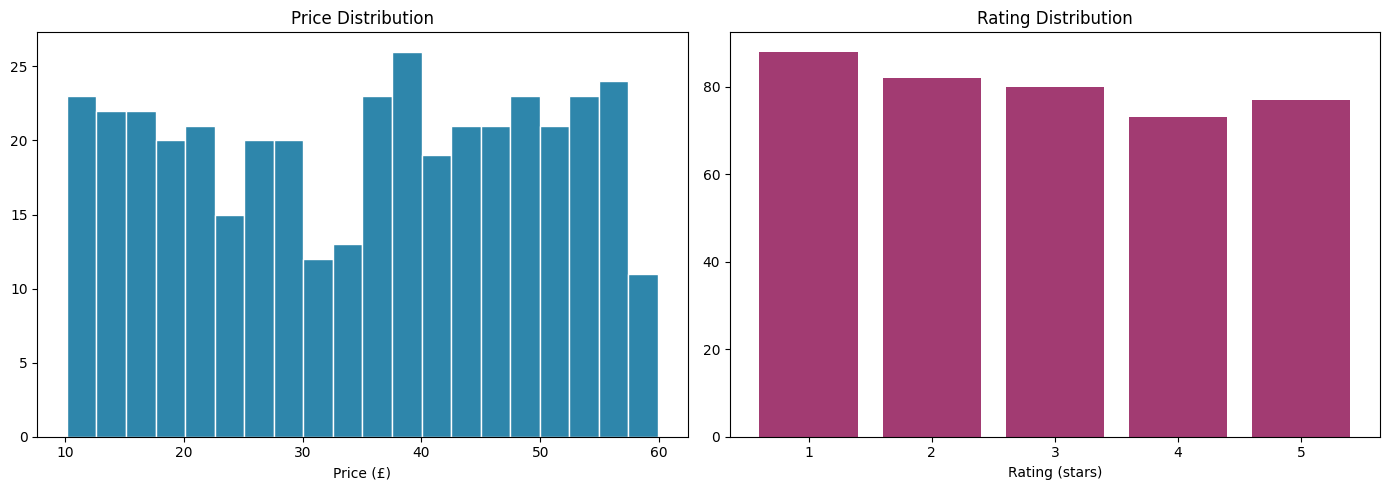

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(df['price'], bins=20, color='#2E86AB', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (£)')

rating_counts = df['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='#A23B72')
axes[1].set_title('Rating Distribution')
axes[1].set_xlabel('Rating (stars)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodSoft_Task1/task5_chart.png', dpi=150)
plt.show()

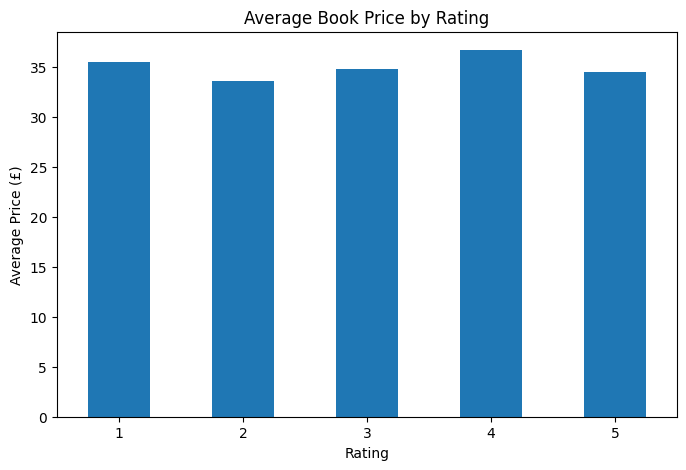

In [16]:
avg_price_rating = df.groupby("rating")["price"].mean()

plt.figure(figsize=(8, 5))
avg_price_rating.plot(kind="bar")

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=0)

plt.show()

In [17]:
df.to_csv('/content/drive/MyDrive/CodSoft_Task1/scraped_books.csv', index=False)
print("Saved successfully! Task 5 done.")

Saved successfully! Task 5 done.
